In [10]:
from Bio.PDB import PDBParser
import numpy as np

def extract_plddt_multichain(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("prot", pdb_file)

    plddt = []
    chain_ids = []
    res_labels = []
    global_index = []

    idx = 0

    for model in structure:
        for chain in model:
            for res in chain:

                if res.id[0] != " ":
                    continue

                ca = res["CA"] if "CA" in res else None
                if ca is None:
                    continue

                plddt.append(ca.get_bfactor())
                chain_ids.append(chain.id)
                res_labels.append(res.id[1])
                global_index.append(idx)

                idx += 1

    return (
        np.array(plddt),
        np.array(chain_ids),
        np.array(res_labels),
        np.array(global_index)
    )

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

colors = [
    "red",          # 0–50
    "yellow",       # 50–70
    "deepskyblue",  # 70–90
    "blue"          # 90–100
]

bounds = [0, 50, 70, 90, 100]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

In [6]:
def get_chain_breaks(chain_ids):
    breaks = []
    for i in range(1, len(chain_ids)):
        if chain_ids[i] != chain_ids[i-1]:
            breaks.append(i)
    return breaks

In [12]:
def plot_multichain_plddt(plddt, chain_ids):
    x = np.arange(len(plddt))

    plt.figure(figsize=(12, 4))

    plt.scatter(
        x,
        plddt,
        c=plddt,
        cmap=cmap,
        norm=norm,
        s=10
    )

    # chain 分割线
    breaks = get_chain_breaks(chain_ids)
    for b in breaks:
        plt.axvline(b, color="black", linewidth=0.8, alpha=0.5)

    plt.colorbar(label="pLDDT (ChimeraX-style)")
    plt.xlabel("Residue index (all chains concatenated)")
    plt.ylabel("pLDDT")
    plt.title("AlphaFold multichain confidence map")
    xmin = 0
    xmax = len(plddt) - 1
    plt.xlim(xmin, xmax)
    plt.ylim(0, 100)

    plt.show()

In [8]:
def plot_multichain_strip(plddt, chain_ids):
    plt.figure(figsize=(12, 2))

    plt.imshow(
        [plddt],
        cmap=cmap,
        norm=norm,
        aspect="auto"
    )

    breaks = get_chain_breaks(chain_ids)
    for b in breaks:
        plt.axvline(b, color="black", linewidth=1)

    plt.yticks([])
    plt.xlabel("Residue index (all chains concatenated)")
    plt.title("ChimeraX-style multichain pLDDT strip")
    plt.colorbar(label="pLDDT")

    plt.show()

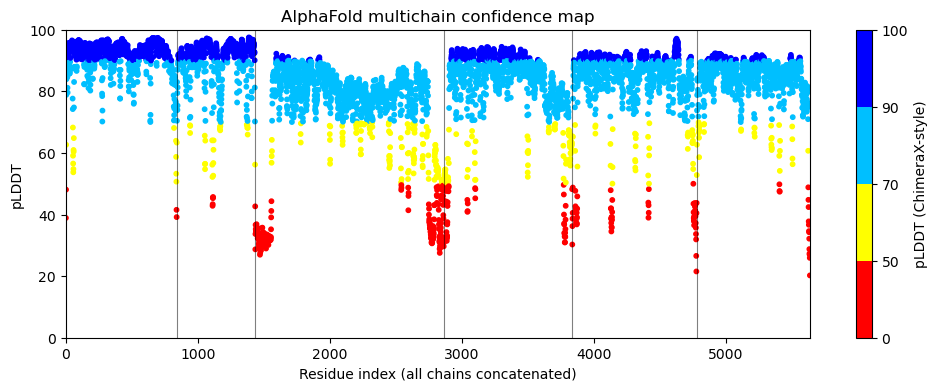

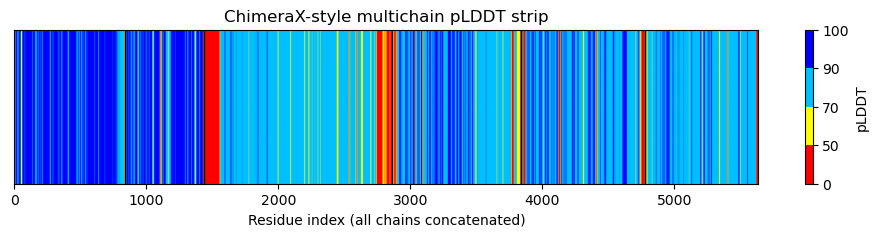

In [13]:
pdb_file = r"N:\08_NK_structure_prediction\XL_MOPLC\data\CORVET\assembled_complex\output\best_complex.pdb"

plddt, chain_ids, res_labels, idx = extract_plddt_multichain(pdb_file)

plot_multichain_plddt(plddt, chain_ids)
plot_multichain_strip(plddt, chain_ids)